# POKEMON

### Analitika kitabxanalarının yüklənməsi və Datasetin Gətirilməsi

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_excel(r"C:\Users\ASUS\Desktop\Phyton\Python Layihe\Pokemon\Pokemon.xlsx")

#### Datasetdə ən çox yayılmış Pokemon növü hansıdır? Bu tip nə qədər Pokemon var?

In [25]:
top_type = df["type1"].value_counts().idxmax()
count = df["type1"].value_counts().max()
print(top_type, count)

water 114


#### Digər növləri ilə müqayisədə həddindən artıq yüksək və ya aşağı statistikaya malik hər hansı Pokemon varmı?

In [27]:
import pandas as pd

df = pd.read_excel("pokemon.xlsx")

# Stat sütunları
stats = ["hp", "attack", "defense", "sp_attack", "sp_defense", "speed"]

high_outliers = pd.DataFrame()
low_outliers = pd.DataFrame()

for col in stats:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    high_outliers = pd.concat([high_outliers, df[df[col] > upper]])
    low_outliers = pd.concat([low_outliers, df[df[col] < lower]])

# Yalnız unikal Pokemon-lar
high_outliers = high_outliers.drop_duplicates(subset="name")
low_outliers = low_outliers.drop_duplicates(subset="name")

print("Yüksək statistika outlier-ləri:")
print(high_outliers[["name", "attack", "speed", "hp"]])

print("\nAşağı statistika outlier-ləri:")
print(low_outliers[["name", "attack", "speed", "hp"]])

Yüksək statistika outlier-ləri:
           name  attack  speed   hp
39   Wigglytuff      70     45  140
112     Chansey       5     50  250
130      Lapras      85     60  130
133    Vaporeon      65     65  130
142     Snorlax     110     30  160
201   Wobbuffet      33     33  190
241     Blissey      10     55  255
288     Slaking     160    100  150
296    Hariyama     120     50  144
319     Wailmer      70     60  130
320     Wailord      90     60  170
425    Drifblim      80     80  150
445    Munchlax      85      5  135
486    Giratina     120     90  150
593   Alomomola      75     65  165
715     Xerneas     131     99  126
716     Yveltal     131     99  126
717     Zygarde     100     85  216
789    Solgaleo     137     97  137
790      Lunala     113     97  137
797    Guzzlord     101     43  223
213   Heracross     185     75   80
382     Groudon     180     90  100
383    Rayquaza     180    115  105
444    Garchomp     170     92  108
796     Kartana     181    109  

#### Pokemonun capture rate ilə onun base total arasında əlaqə varmı? Bəs onun nadirliyi (legendary və ya deyil)?

Correlation: -0.7121201962428769


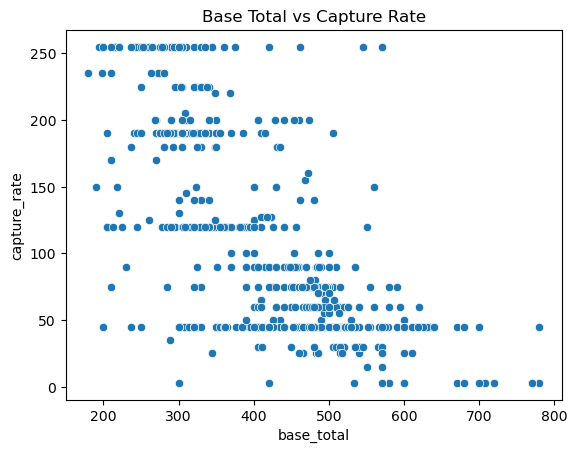

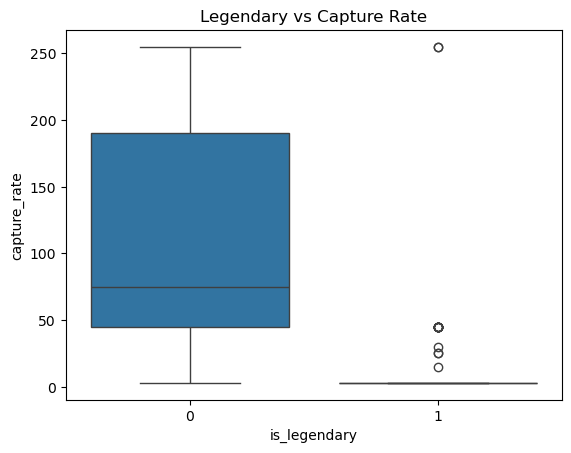

is_legendary
0    106.506849
1     17.985714
Name: capture_rate, dtype: float64


In [14]:
correlation = df["capture_rate"].corr(df["base_total"])
print("Correlation:", correlation)
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x="base_total", y="capture_rate", data=df)
plt.title("Base Total vs Capture Rate")
plt.show()
sns.boxplot(x="is_legendary", y="capture_rate", data=df)
plt.title("Legendary vs Capture Rate")
plt.show()
print(df.groupby("is_legendary")["capture_rate"].mean())

#### Hansı Pokemon ən yüksək hücum statistikasına malikdir?

In [15]:
df.loc[df["attack"].idxmax(), ["name", "attack"]]

name      Heracross
attack          185
Name: 213, dtype: object

#### Base total ilə HP, Attack, Defense, Special Attack, Special Defense və Speed kimi digər atributların hər biri arasında correlation nədir?

In [20]:
cols = ["base_total","hp","attack","defense","sp_attack","sp_defense","speed"]

correlation = df[cols].corr()

print(correlation["base_total"])
df[["hp","attack","defense","sp_attack","sp_defense","speed"]].corrwith(df["base_total"])

base_total    1.000000
hp            0.621062
attack        0.729998
defense       0.630151
sp_attack     0.740986
sp_defense    0.717958
speed         0.547575
Name: base_total, dtype: float64


hp            0.621062
attack        0.729998
defense       0.630151
sp_attack     0.740986
sp_defense    0.717958
speed         0.547575
dtype: float64

#### Əfsanəvi və əfsanəvi olmayan Pokemonun ortalama hücum  arasında əhəmiyyətli fərq varmı?

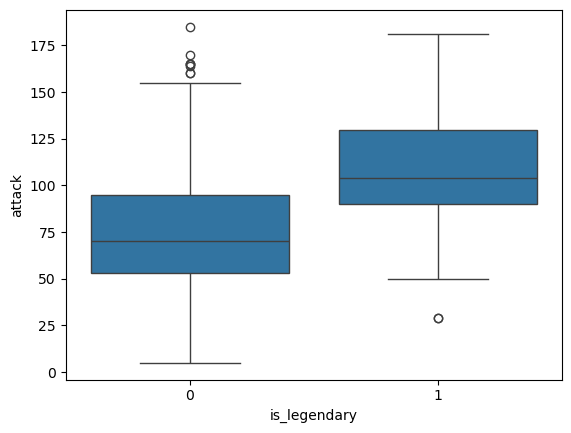

p-value: 1.5791186751463342e-18


In [26]:
df.groupby("is_legendary")["attack"].mean()
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="is_legendary", y="attack", data=df)
plt.show()
from scipy.stats import ttest_ind

legendary = df[df["is_legendary"] == 1]["attack"]
normal = df[df["is_legendary"] == 0]["attack"]

t_stat, p_value = ttest_ind(legendary, normal)

print("p-value:", p_value)

#### Hansı tip 1 və tip 2 kombinasiyaları Pokemonlar arasında ən çox yayılmışdır?

In [30]:
 df.groupby(["type1", "type2"]).size().sort_values(ascending=False).head(10)

type1   type2   
normal  flying      26
grass   poison      14
bug     flying      13
        poison      11
water   ground       9
        flying       7
rock    water        6
grass   flying       6
rock    ground       6
fire    fighting     6
dtype: int64

#### Pokemonun çəkisi və boyu arasında korrelyasiya varmı?

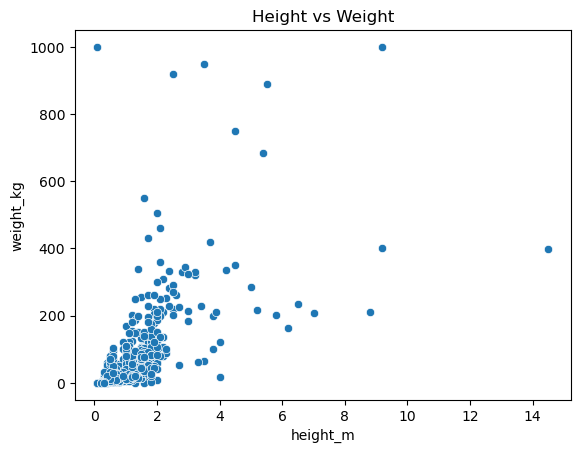

In [32]:
df["height_m"].corr(df["weight_kg"])
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x="height_m", y="weight_kg", data=df)
plt.title("Height vs Weight")
plt.show()

#### Hansı nəsil (generation) ən yüksək ortalama sürətə malikdir?

In [38]:
df.groupby("generation")["speed"].mean().sort_values(ascending=False)

generation
1    70.152318
4    70.074766
6    66.652778
5    66.519231
3    63.577778
7    63.329114
2    61.610000
Name: speed, dtype: float64

#### Base total paylanması əfsanəvi və əfsanəvi olmayan Pokemon arasında necə dəyişir?

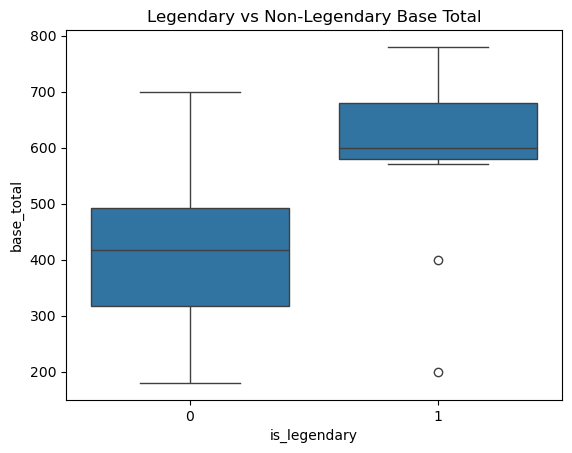

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="is_legendary", y="base_total", data=df)
plt.title("Legendary vs Non-Legendary Base Total")
plt.show()

#### Müxtəlif Pokemon tipləri arasında Defense paylanmasında əhəmiyyətli fərq varmı?

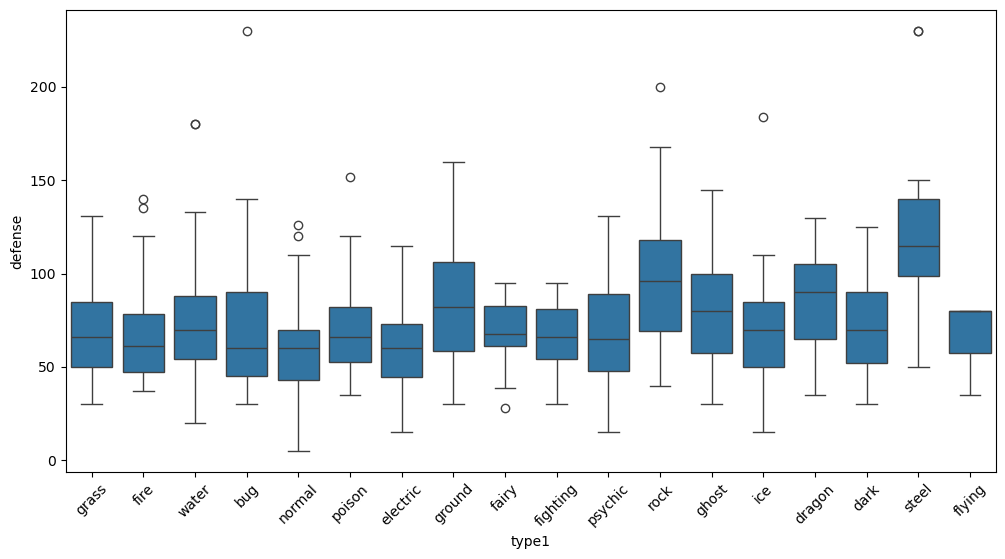

p-value: 5.059735488193532e-20


In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(x="type1", y="defense", data=df)
plt.xticks(rotation=45)
plt.show()
from scipy.stats import f_oneway

groups = [group["defense"].values for name, group in df.groupby("type1")]

f_stat, p_value = f_oneway(*groups)

print("p-value:", p_value)

#### Pokemonun adını input kimi qəbul edən və onun statistikalarının olduğu lüğətini qaytaran funksiya yazın.

In [42]:
import pandas as pd


df = pd.read_excel("pokemon.xlsx")

def get_pokemon_stats(name):
    """
    Pokémon adını input kimi qəbul edir
    və onun bütün statistikalarını dictionary şəklində qaytarır.
    """
   
    pokemon = df[df["name"].str.lower() == name.lower()]
    
    if pokemon.empty:
        return f"{name} adlı Pokémon tapılmadı."
    
    
    stats = pokemon.iloc[0].to_dict()
    return stats


pokemon_name = input("Pokémon adı daxil edin: ")
result = get_pokemon_stats(pokemon_name)
print(result)

Pokémon adı daxil edin:  Gloom


{'#': 44, 'name': 'Gloom', 'type1': 'grass', 'type2': 'poison', 'base_total': 395, 'hp': 60, 'attack': 65, 'defense': 70, 'sp_attack': 85, 'sp_defense': 75, 'speed': 40, 'height_m': 0.8, 'weight_kg': 8.6, 'is_legendary': 0, 'generation': 1, 'capture_rate': 120, 'base_happiness': 70, 'percentage_male': 50.0}


#### Percentage_male sütununda boş dəyərləri öz tipinin ortalaması ilə doldurun

In [43]:
import pandas as pd


df = pd.read_excel("pokemon.xlsx")


df["percentage_male"] = df.groupby("type1")["percentage_male"].transform(
    lambda x: x.fillna(x.mean())
)


print(df["percentage_male"].isna().sum())  

0


#### Daha çox kişiyə yaxın olan pokemonlar daha güclüdür, yoxsa qadına yaxın olanlar?

Correlation: 0.09846151993751448


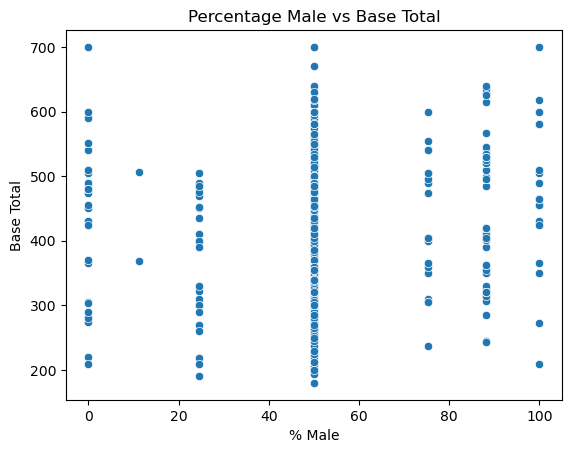

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6980\3914902077.py:13: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



gender_group
Female-biased    370.076923
Balanced         403.750499
Male-biased      437.919463
Name: base_total, dtype: float64

In [62]:
correlation = df["percentage_male"].corr(df["base_total"])
print("Correlation:", correlation)
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x="percentage_male", y="base_total", data=df)
plt.title("Percentage Male vs Base Total")
plt.xlabel("% Male")
plt.ylabel("Base Total")
plt.show()
df["gender_group"] = pd.cut(df["percentage_male"], bins=[0,40,60,100], labels=["Female-biased","Balanced","Male-biased"])

df.groupby("gender_group")["base_total"].mean()
df.groupby("gender_group", observed=True)["base_total"].mean()

#### Əfsanəvi və ya əfsanəvi olmayan pokemonların ortalama çəkiləri və boyları arasında önəmli bir fərq var?

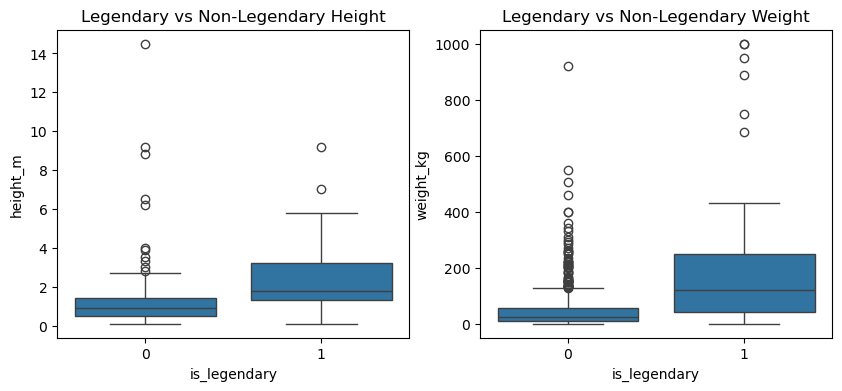

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# Boy
plt.subplot(1,2,1)
sns.boxplot(x="is_legendary", y="height_m", data=df)
plt.title("Legendary vs Non-Legendary Height")

# Çəki
plt.subplot(1,2,2)
sns.boxplot(x="is_legendary", y="weight_kg", data=df)
plt.title("Legendary vs Non-Legendary Weight")

plt.show()

#### Hansı tip1 və tip2 kombinasiyası daha xoşbəxtdir?

In [48]:
import pandas as pd


df = pd.read_excel("pokemon.xlsx")


df["type2"] = df["type2"].fillna("None")


happiness_by_type = df.groupby(["type1", "type2"])["base_happiness"].mean().sort_values(ascending=False)

print(happiness_by_type.head(5))  

type1    type2
grass    grass    100.0
psychic  grass    100.0
         fire     100.0
fire     steel    100.0
         water    100.0
Name: base_happiness, dtype: float64


#### Tiplər üzrə ortalama çəki və boyları tapın

In [49]:
import pandas as pd


df = pd.read_excel("pokemon.xlsx")


df["type2"] = df["type2"].fillna("None")


avg_size = df.groupby("type1")[["height_m", "weight_kg"]].mean().sort_values(by="weight_kg", ascending=False)

print(avg_size)

          height_m   weight_kg
type1                         
steel     1.875000  188.841667
ground    1.340741  150.044444
dragon    1.937037  107.125926
ice       1.208696  103.260870
rock      1.330000   94.270000
ghost     1.251852   69.570370
dark      1.296552   69.096552
fire      1.168000   66.096000
fighting  1.196429   58.675000
psychic   1.063462   57.328846
flying    1.166667   52.000000
water     1.283333   51.071930
normal    1.024752   46.158416
electric  0.981579   37.944737
poison    1.160000   33.830000
grass     0.938961   33.255844
bug       0.883333   33.083333
fairy     0.794444   23.555556


### Mən oynamaq üçün ən ideal pokemonu seçmək istəsəm, hansını seçməliyəm? Bunun üçün özünüzə uyğun xüsusi bir analiz aparın və seçdiyiniz pokemonu əsaslandırın

In [51]:

non_legendary = df[df["is_legendary"] == 0].copy()


non_legendary["overall_score"] = non_legendary["balance_score"] + non_legendary["base_happiness"]


best_pokemon = non_legendary.sort_values(by="overall_score", ascending=False).iloc[0]

best_pokemon[["name", "type1", "type2", "balance_score", "base_happiness", "overall_score"]]

name              Garchomp
type1               dragon
type2               ground
balance_score          700
base_happiness          70
overall_score          770
Name: 444, dtype: object

#### Apardığınız analizlərin nəticəsinə uyğun olaraq vizuallaşdırmalar aparın və bir dashboard qurun

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go



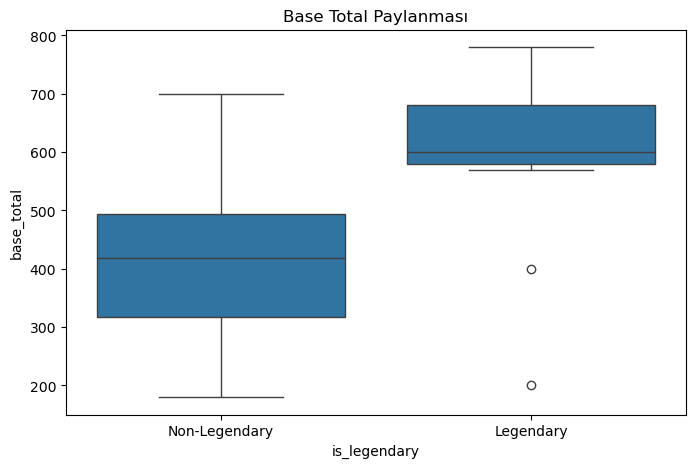

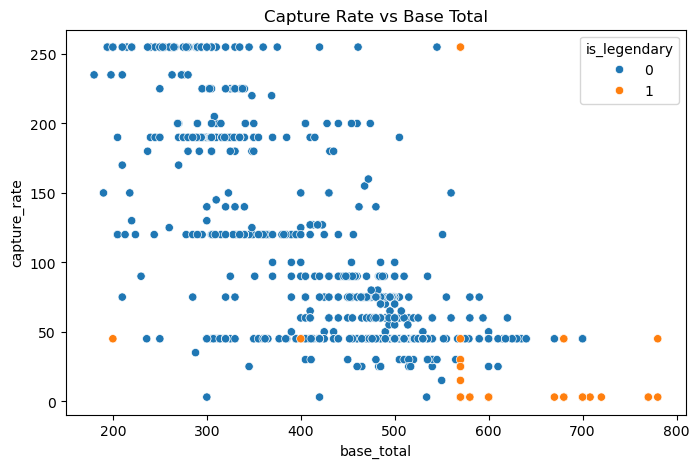

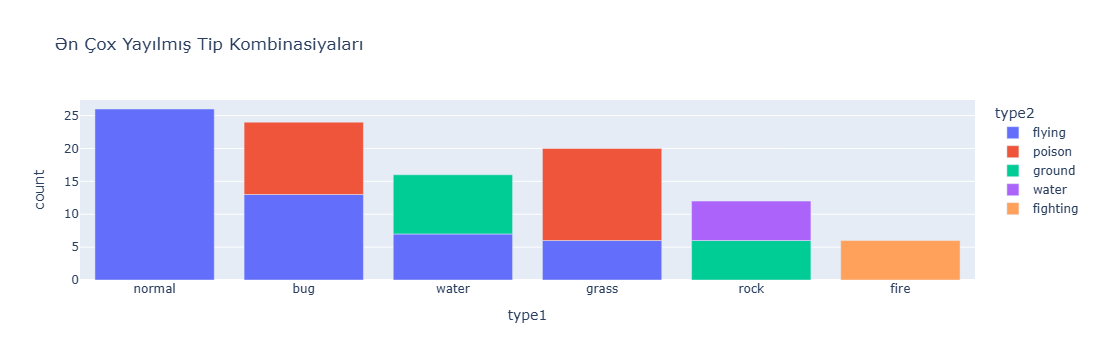

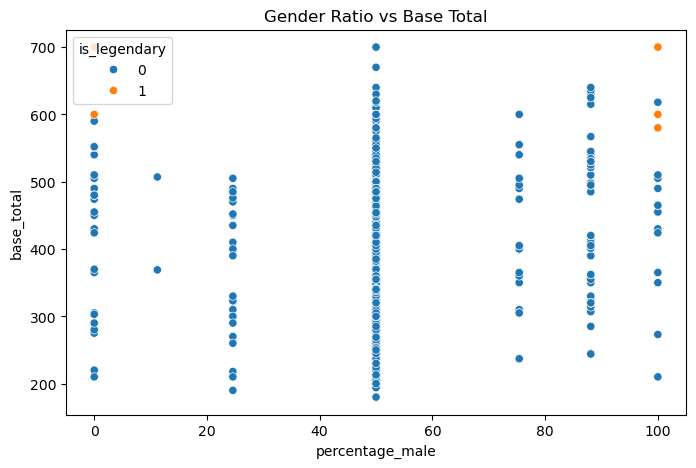

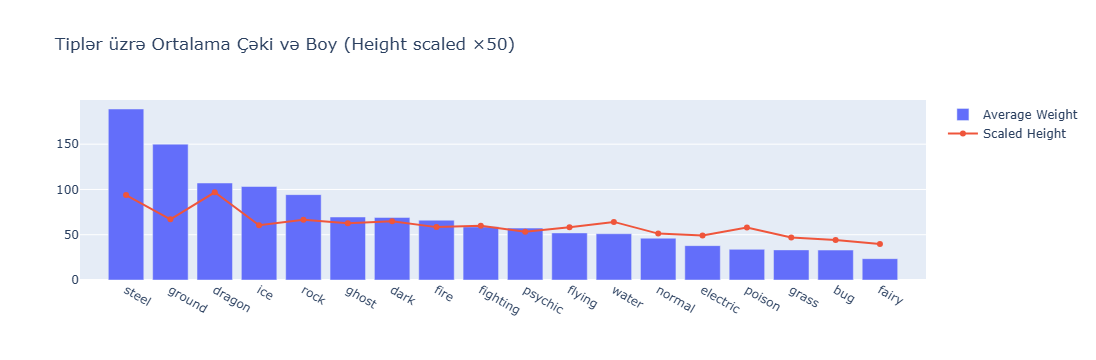

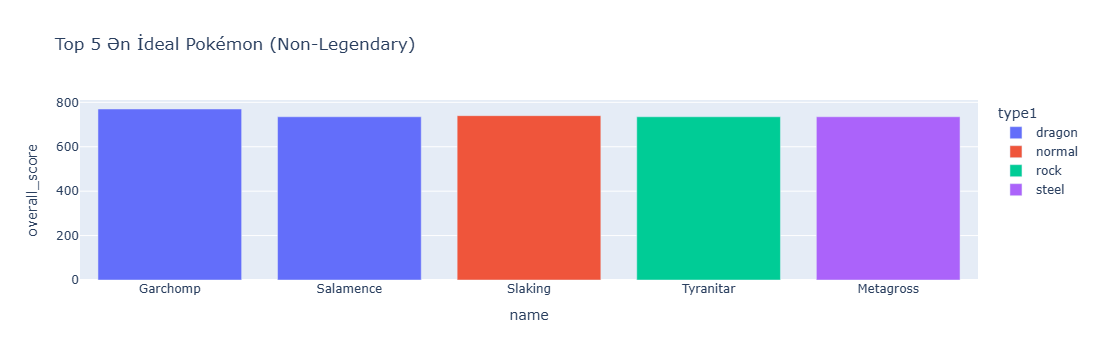

In [61]:
plt.figure(figsize=(8,5))
sns.boxplot(x="is_legendary", y="base_total", data=df)
plt.xticks([0,1], ["Non-Legendary", "Legendary"])
plt.title("Base Total Paylanması")
plt.show()
plt.figure(figsize=(8,5))
sns.scatterplot(x="base_total", y="capture_rate", hue="is_legendary", data=df)
plt.title("Capture Rate vs Base Total")
plt.show()
top_types = df.value_counts(["type1", "type2"]).head(10).reset_index(name="count")
fig = px.bar(top_types, x="type1", y="count", color="type2", title="Ən Çox Yayılmış Tip Kombinasiyaları")
fig.show()
plt.figure(figsize=(8,5))
sns.scatterplot(x="percentage_male", y="base_total", hue="is_legendary", data=df)
plt.title("Gender Ratio vs Base Total")
plt.show()
avg_size = df.groupby("type1")[["height_m", "weight_kg"]].mean().sort_values(by="weight_kg", ascending=False).reset_index()

fig = go.Figure()
fig.add_trace(go.Bar(x=avg_size["type1"], y=avg_size["weight_kg"], name="Average Weight"))
fig.add_trace(go.Scatter(x=avg_size["type1"], y=avg_size["height_m"]*50, mode='lines+markers', name="Scaled Height"))
fig.update_layout(title="Tiplər üzrə Ortalama Çəki və Boy (Height scaled ×50)")
fig.show()
df["balance_score"] = df[["hp","attack","defense","sp_attack","sp_defense","speed"]].sum(axis=1)
non_legendary = df[df["is_legendary"]==0].copy()
non_legendary["overall_score"] = non_legendary["balance_score"] + non_legendary["base_happiness"]

top5 = non_legendary.sort_values("overall_score", ascending=False).head(5)
fig = px.bar(top5, x="name", y="overall_score", color="type1", title="Top 5 Ən İdeal Pokémon (Non-Legendary)")
fig.show()